This notebook gives an overview and examples of how to use this code.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from s3topologies import S3, EllipticSpace, LensSpace

To initialize an instance of a spherical topology (either a three-sphere or a lens space), one can specify the following parameters:

- ``OmegaK`` : Curvature density parameter $\Omega_K$. Has to be negative. Default is $-10^{-3}$.
- ``lmax`` : Maximum multipole $\ell$ to include in the analysis ($\ell_{\min}$ is necessarily 2). Default is 20.
- ``compute_kmax_internally`` : If **True**, it will compute kmax up to the value needed to achieve the given accuracy of $C_\ell$'s. Default is **False**.
- ``compute_kmax_tol`` : Parameter to specify the accuracy of the $C_{\ell}$'s. Specifically, determined by the accuracy of the $S^3$ $C_\ell$'s calculated manually compared to CAMB. Default is 0.005, meaning the manual $C_{\ell}^{S^3}$ will replicate the $C_{\ell}^{S^3}$ from CAMB with 99.5% accuracy.
- ``kmax`` : If ``compute_kmax_internally`` is **False**, one can manually specify $k_{\max}$. In general, a good range of values to consider is $10^{-4}~{\rm Mpc}^{-1} \leq k_{\max}\leq 7\times 10^{-2}~{\rm Mpc}^{-1}$. Default is $10^{-3}~{\rm Mpc}^{-1}$. 
- ``accboost`` : The accuracy boost value to specify in CAMB. Default is 2.
- ``onlyTT`` : If **True**, only the temperature ($TT$) CMB correlation matrix will be calculated. Otherwise, the $E$-mode polarization will also be calculated ($TT$, $TE$, and $EE$). Default is **False**.

If considering a lens space, one can specify its defining parameters:
- ``p`` : Integer specifying the lens space $L(p,q)$. Defaults to 5.
- ``q`` : Integer specifying the lens space $L(p,q)$. Defaults to 2.   
(Remember that $1\leq q < p$ and $p$ and $q$ have to be coprime. $L(1,1)$ is the same as the covering space $S^3$, $L(2,1)$ is the isotropic Elliptic space and all Lens Spaces of the form $L(p,1)$ are homogeneous.)
- ``obs_ang`` : similar to $(x_0,y_0,z_0)$ in the Euclidean setting, it is the origin with respect to which the topology defining generators are defined. It is specified by the three toroidal angles $(\chi_0,{\xi_+}_0,{\xi_-}_0)$. As in the Euclidean case, there are only really two degrees of freedom: $\chi_0$ and ${\xi_+}_0-{\xi_-}_0$. The one that matters most is $\chi_0$ and in some sense is the distance to one of the two main axes. When $\chi_0=0$, the observer lies on one of the great circles defining the lens spaces, and as $\chi_0\rightarrow\pi/2$, the observer sits on the other great circle. Note that $0\leq \chi_0\leq \pi/2$, and $0\leq {\xi_+}_0,{\xi_-}_0 \leq 2\pi$. Default is $(\chi_0,{\xi_+}_0,{\xi_-}_0)=(0,0,0)$.

One can also specify the usual $\Lambda$-CDM cosmological parameters in CAMB:
- ``ombh2`` : Baryon density parameter $\Omega_b h^2$. Default is 0.022.
- ``omch2`` : Cold dark matter density parameter $\Omega_c h^2$. Default is 0.122.
- ``mnu`` : Sum of neutrino masses $\sum_i m_{\nu_i}$ in eV. Default is 0.06.
- ``H0`` : Hubble constant $H_0$ in km/s/Mpc. Default is 67.5.
- ``tau`` : Optical depth at reionization $\tau_{\rm reio}$. Default is 0.06.
- ``As`` : Scalar primordial power spectrum amplitude $A_s$ at the pivot scale $k_*=0.05~{\rm Mpc}^{-1}$. Default is $2\times 10^{-9}$.
- ``ns`` : Scalar primordial power spectrum tilt $n_s$. Default is 0.965.

There are other arguments related to runtime computations and message outputs:
- ``num_workers`` : The main sum to compute $C_{\ell m\ell\prime m\prime}$ is parallelized. This parameter specifies across how many CPUs that sum is parallelized. The default setting is that it will use half the available CPUs. Each worker process uses ``total_avail_CPUs // num_workers`` threads to do the math.
- ``batchsize`` : The principal sum in $n$ is split into balanced chunks of size ``batchsize``, and so each worker computes the contribution of that chunk of $n$'s at a time. Default is ``None``, which creates up to 1 batch per worker (recommended). Setting it to a smaller value (e.g. 10 or 30) is only useful to keep track of progress with the progress bar.
- ``use_tqdm`` : If **True**, the progress in the computation of $C_{\ell m\ell\prime m\prime}$ is neatly represented by a ``tqdm`` progress bar (recommended when running locally/laptop). Default is `False`, as most SLURM managed clusters are not ``tqdm`` friendly. It will instead show alternative, simpler progress messages.
- ``verbose`` : If **True**, will print progress messages. Note that in order to see the tqdm progress bar, this must be set to **True**. Set to **False** to turn off all progress messages. This can be useful for SLURM managed clusters to avoid excessive printed messages. Default is **True**.

### $S^3$ Example

Let's start by initializing an $S^3$ (three-sphere) object.

In [ ]:
s3_params = {
    'OmegaK': -5e-2,
    'lmax': 8,
    'compute_kmax_internally': True,
    'batchsize': 10,
    'use_tqdm': True,
}

s3 = S3(s3_params)

Looking for optimum kmax for the given lmax...
Convergence reached. kmax is 0.0167947. nmax is 333
This kmax will compute the Cls with an accuracy of 99.527% (target >= 99.500%).


For $S^3$, one can calculate the $C_\ell$'s using CAMB, or manually using formula
$$ C_\ell^{XY} = \frac{4\pi}{R_c} \sum_{n=2}^{n_{\max}} \Delta_\ell^X(k_n)\Delta_\ell^Y(k_n) \frac{\mathcal{P_R}(k_n)}{k_n}$$
where the transfer functions are given by $$\Delta_\ell^X(k_n)\equiv \int d\tau  \, S^X(q_n,\tau)\, R_{n\ell}(\psi(\tau))$$
with $R_{n\ell}$ the hyperspherical radial eigenfunctions and $S^X$ the usual line-of-sight source functions, calculated in CAMB.

Note that because we set `compute_kmax_tol=0.005`, the manual $C_\ell$'s should replicate the CAMB $C_\ell$'s with an accuracy of at least 99.5%.

In [3]:
# CAMB C_ells
Cl_s3_camb = s3.get_Cls()
Cl_s3_manual = s3.get_manual_Cls()

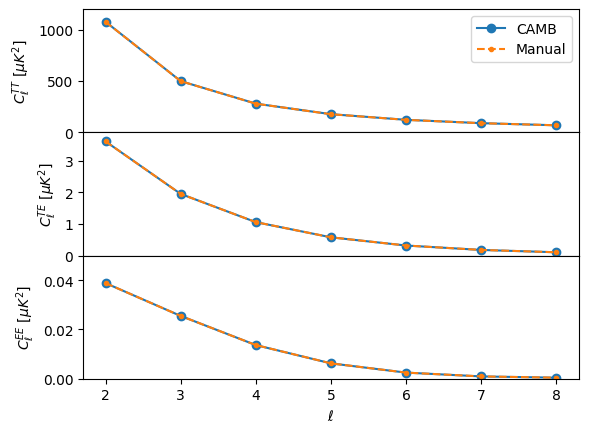

In [4]:
# plot TT, TE, EE power spectra
ell_arr = np.arange(2,s3.lmax+1)
fig,ax = plt.subplots(3,1,sharex=True)
ax[0].plot(ell_arr, Cl_s3_camb[0,:],'-o',label='CAMB')
ax[0].plot(ell_arr, Cl_s3_manual[0,:],'--.',label='Manual')
ax[1].plot(ell_arr, Cl_s3_camb[1,:],'-o')
ax[1].plot(ell_arr, Cl_s3_manual[1,:],'--.')
ax[2].plot(ell_arr, Cl_s3_camb[2,:],'-o')
ax[2].plot(ell_arr, Cl_s3_manual[2,:],'--.')

ax[0].legend()

ax[2].set_xlabel(r'$\ell$')
ax[0].set_ylabel(r'$C_\ell^{TT}~[\mu K^2]$')
ax[1].set_ylabel(r'$C_\ell^{TE}~[\mu K^2]$')
ax[2].set_ylabel(r'$C_\ell^{EE}~[\mu K^2]$')

ax[0].set_ylim([0,1200])
ax[1].set_ylim([0,3.9])
ax[2].set_ylim([0,0.05])

plt.subplots_adjust(hspace=0)

### Elliptic Space $L(2,1)$ Example

Next, let's consider the lens space $L(2,1)$, also known as the elliptic space. This is a special case where the calculation of $C_{\ell m \ell'm'}$ reduces significantly. So we define it as its own instance, as the simplified calculations are much faster than computing the whole matrix for the general case.

For this case, let's only calculate the temperature correlation matrix $TT$.

In [5]:
elliptic_params = s3_params.copy()
elliptic_params.update({'onlyTT':True,
                        'compute_kmax_internally': False,
                        'kmax' : s3.kmax})
elliptic = EllipticSpace(elliptic_params)

For the elliptic space, CMB correlation matrix reduces to
$$ C_\ell^{XY} = \frac{8\pi}{R_c} \sum_{n\in {\rm even}}^{n_{\max}} \Delta_\ell^X(k_n)\Delta_\ell^Y(k_n) \frac{\mathcal{P_R}(k_n)}{k_n}$$


In [6]:
Cl_elliptic = elliptic.get_Cls()

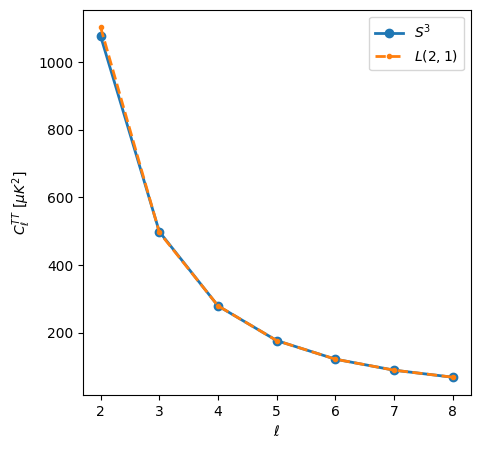

In [7]:
# plot TT power spectrum
plt.figure(figsize=(5,5))
plt.plot(ell_arr, Cl_s3_manual[0,:],'-o',lw=2,label='$S^3$')
plt.plot(ell_arr, Cl_elliptic,'--.',lw=2,label='$L(2,1)$')

plt.legend()

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{TT}~[\mu K^2]$')

plt.subplots_adjust(hspace=0)

For any lens space, we can calculate the full correlation matrix.

In [8]:
elliptic.compute_Clmlpmp()

The elliptic space matrix is fully diagonal. However, there are slight differences from the covering space, which can be seen in the normalized matrix: $C_{\ell m \ell'm'}/\sqrt{C_\ell^{S^3} C_{\ell'}^{S^3}}$

In [9]:
elliptic.get_C_matrix(norm=True)

array([[1.02458294, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.02458294, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.02458294, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.99997276, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.99997276,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.99997276]], shape=(77, 77))

### General Lens Space Example

Now let's look at a general lens space. As an example, let's consider $L(15,2)$ for temperature and $E$-mode polarization.

In [10]:
lens_params = elliptic_params.copy()
lens_params.update({'onlyTT':False,
                    'p' : 15,
                    'q' : 2,
                    'obs_ang' : [0,0,0]})

lens = LensSpace(lens_params)

We can compute the full correlation matrix.

In [11]:
lens.compute_Clmlpmp()

Clmlpmp computation started. nmax is 333
Distributing sum in n across 4 parallel CPU cores...


Computing batches: 100%|██████████| 34/34 [00:00<00:00, 57.43it/s, n_processed=332/332]

Time taken: 3.96s


We can plot the full correlation matrix, normalized to $\sqrt{C_\ell^{S^3} C_{\ell'}^{S^3}}$:

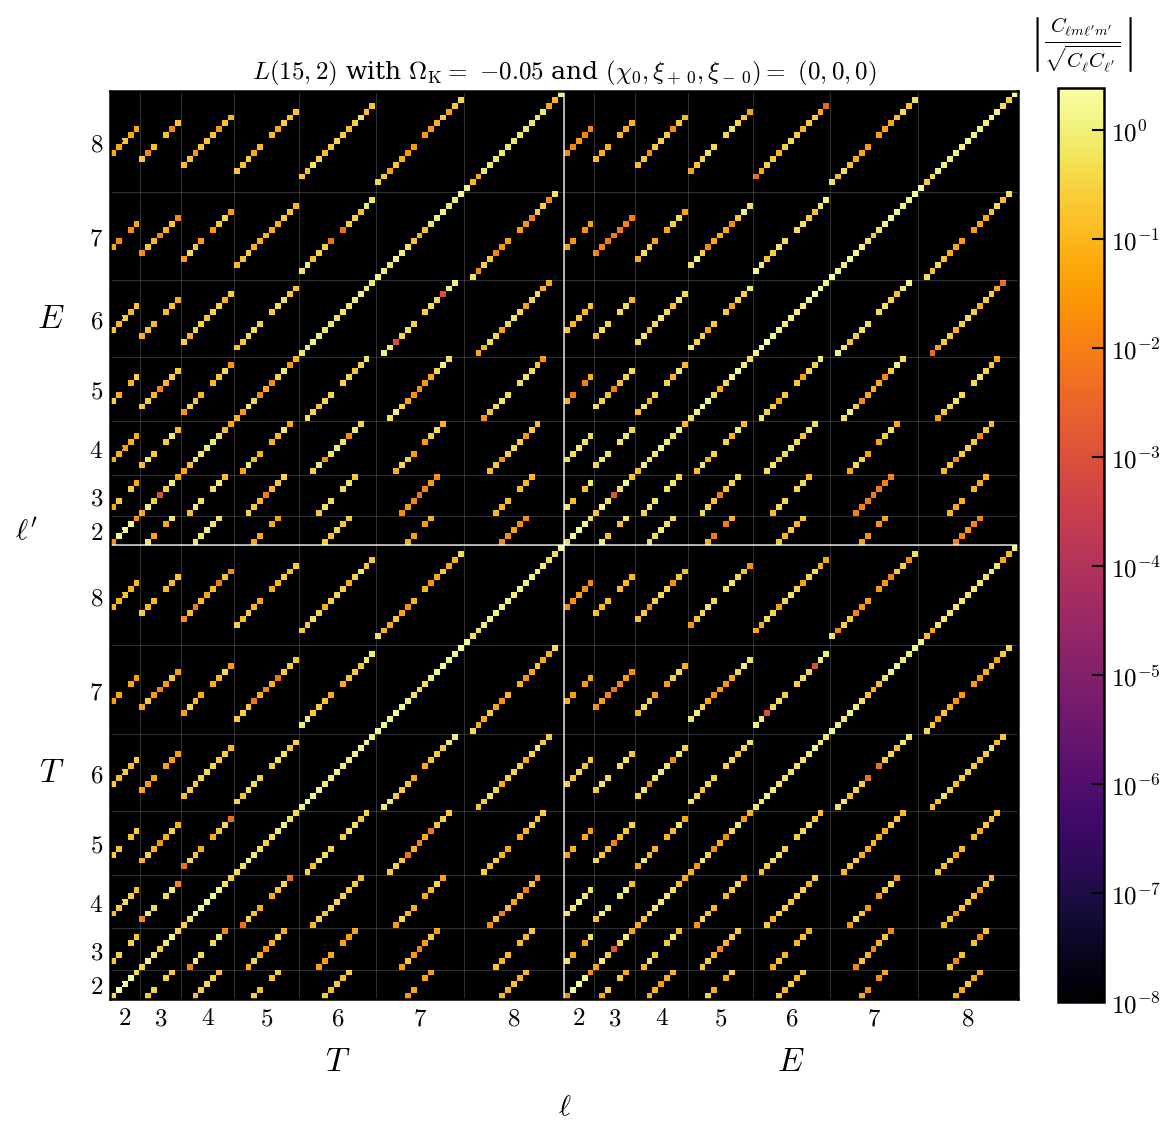

In [12]:
fig, ax = lens.plot_Clmlpmp()

We can also show the matrix in $m$-ordering. For cases when $q=1$, or where $\chi_0=0$, the $m$-ordered matrix will be block-diagonal.

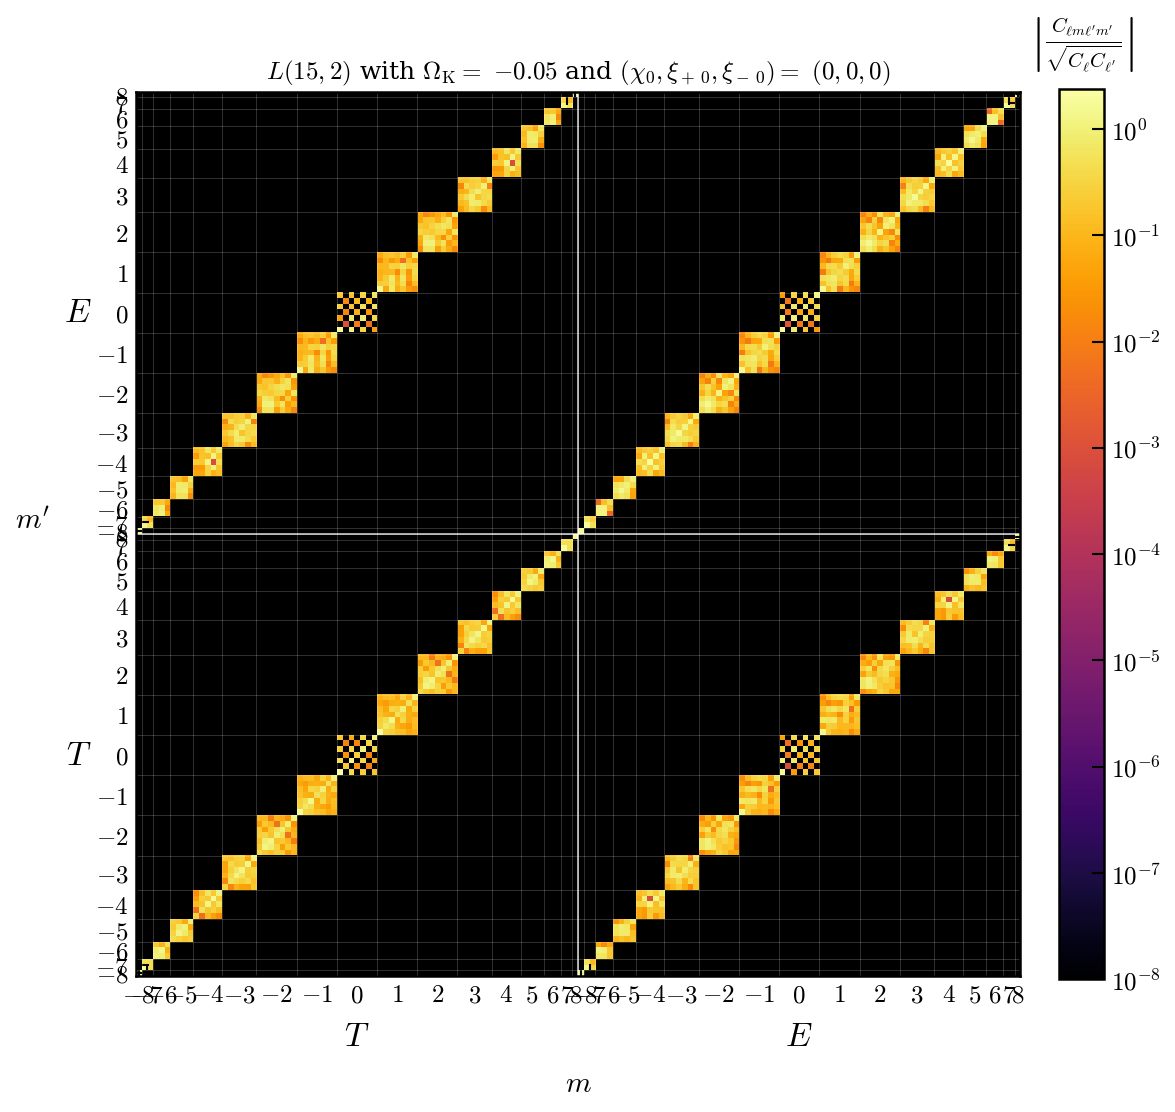

In [13]:
fig, ax = lens.plot_Clmlpmp(m_ordering=True)

One can also plot only the non-negative $m$-values in $m$-ordering by setting `positive_m_only=True`.

Now let's try an off-axis example. Note that computing the lens spaces can get expensive, especially if $\chi_0\neq 0$ and for large $n_{\max}\gtrsim 600$. It is recommended to compute these matrices on a cluster. Smaller matrices can be computed locally.

In [14]:
lens_params.update({'obs_ang' : [0.3,0.1,0.4]})

lens = LensSpace(lens_params)

In [15]:
lens.compute_Clmlpmp()

Clmlpmp computation started. nmax is 333
Distributing sum in n across 4 parallel CPU cores...


Computing batches: 100%|██████████| 34/34 [00:02<00:00, 12.91it/s, n_processed=332/332]


Time taken: 5.50s


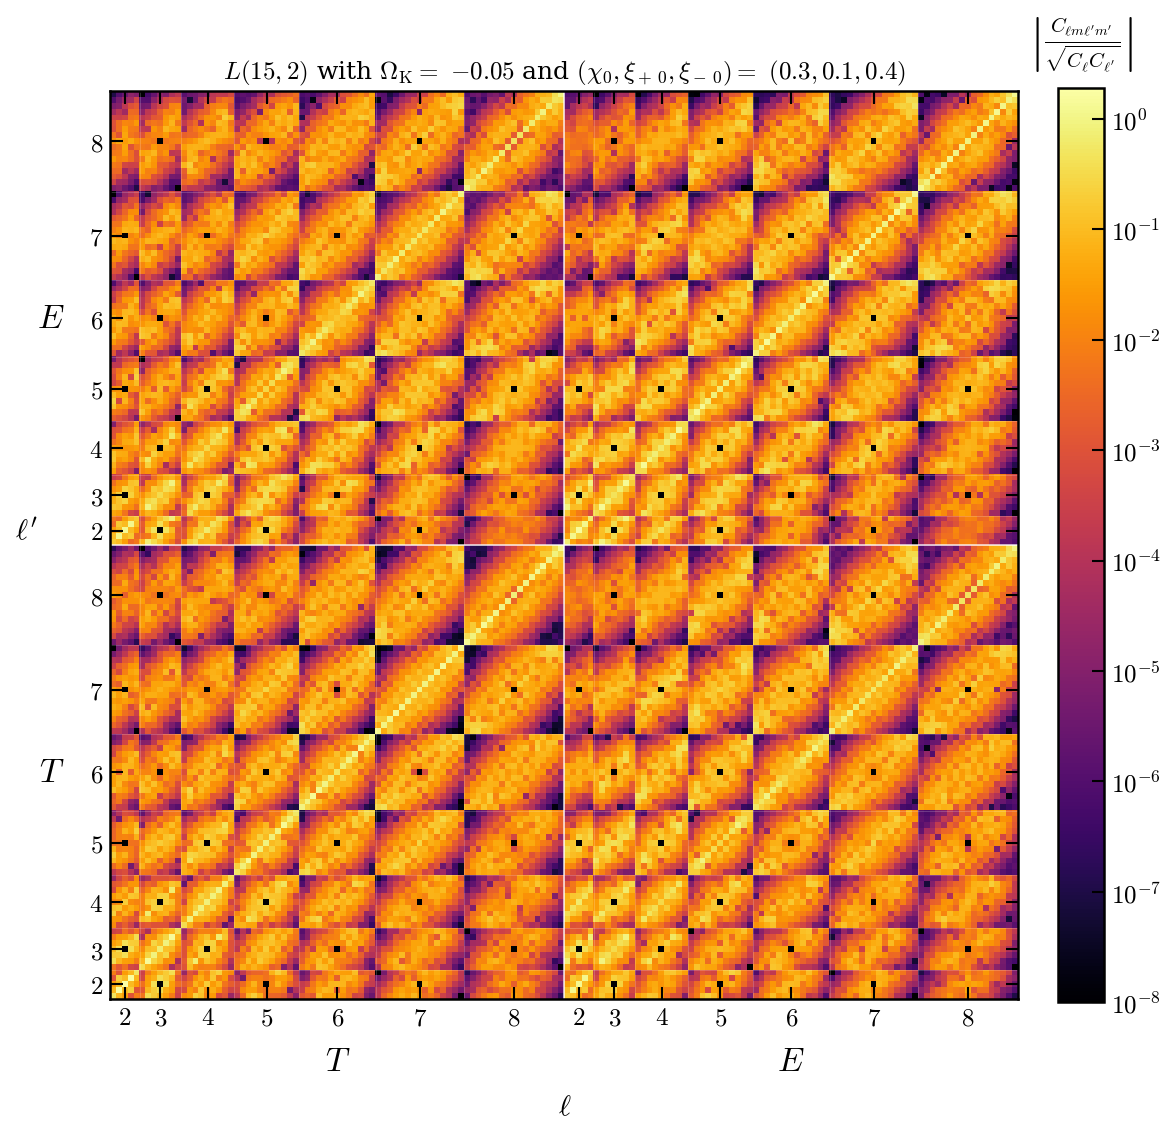

In [16]:
fig, ax =lens.plot_Clmlpmp()

There is also an additional setting to save the plot to a file if desired by specifying ``filename``.

Now let's calculate the Kullback-Leibler (KL) divergence between $L(15,2)$ and the covering space $S^3$ of the same curvature. The KL divergence is given by:
$$ D_{\mathrm{KL}}(P_1 || P_2) = \int \mathrm{d}\bm{x} \,\, P_1(\bm{x}) \ln\, \left[\frac{P_1(\bm{x})}{P_2(\bm{x})} \right] . $$

We can calculate the KL divergence in the forward direction &mdash; $P_1=L(p,q)$ and $P_2=S^3$ &mdash; or in the backward direction &mdash; $P_1=S^3$ and $P_2=L(p,q)$.

In [18]:
# Forward KL first, Backward KL second
lens.compute_KL()

array([   72.18409435, 11342.83399163])

One can also calculate the KL divergence for only a subset of the matrix, specified by $\ell_{\min}$ and $\ell_{\max}$.

In [19]:
lens.compute_KL(lmin=3,lmax=6)

array([  33.07888755, 1195.53572439])

One can also compare the lens space to $S^3$ of a different curvature:

In [20]:
lens.compute_KL(s3_omk=-1e-3)

array([   72.460528  , 10314.47428187])